# Scaling with Prior Mean

When inputs dimensions have different scales, they need to be standardized for GP regression.
On the other hand, informative prior mean often require input to be in its original scale.

This notebook provides an example for combining the two requirements.

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.means import Mean, ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CGLmcVariationalStrategy
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x[..., 0] * 20 * 3.14) * torch.cos(x[..., 1] * 2 * 3.14)


def std(x):
    return x[..., 0] + x[..., 1] + 0.1


N = 500
x = torch.stack(
    [
        torch.rand(N, device=device) * 0.1,
        torch.rand(N, device=device) * 1.0,
    ],
    dim=1,
)

y = (mean(x) + torch.randn(x.shape[0], device=device).mul(std(x))).squeeze()

q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)

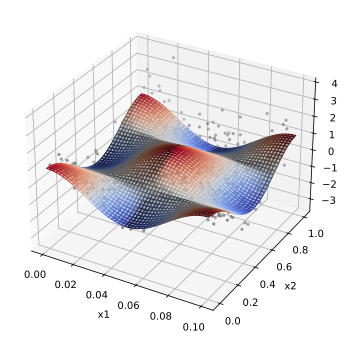

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

x1_grid = torch.linspace(0, 0.1, 50)
x2_grid = torch.linspace(0, 1.0, 50)
X1, X2 = torch.meshgrid(x1_grid, x2_grid, indexing="ij")
x_grid = torch.stack([X1.flatten(), X2.flatten()], dim=1)
Z = mean(x_grid).reshape(50, 50)

ax.plot_surface(
    X1.numpy(),
    X2.numpy(),
    Z.numpy(),
    facecolors=plt.cm.coolwarm(
        (Z.numpy() - Z.numpy().min()) / (Z.numpy().max() - Z.numpy().min())
    ),
    alpha=0.4,
)

# Scatter
ax.scatter(
    x[:, 0].cpu().numpy(),
    x[:, 1].cpu().numpy(),
    y.cpu().numpy(),
    s=5,
    color="gray",
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
plt.tight_layout()
plt.show()

## Prior mean

In [ ]:
class PriorMean(Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean(x)

## Define models and likelihoods

In [ ]:
class Unscaler(torch.nn.Module):
    """Inverse of StandardScaler: maps standardized input back to original scale."""

    def __init__(self, X_scale, X_mean):
        super().__init__()
        self.register_buffer("X_scale", X_scale)
        self.register_buffer("X_mean", X_mean)

    def forward(self, x):
        x_flattened = x.view(-1, x.shape[-1])
        x_unscaled = x_flattened * self.X_scale + self.X_mean
        return x_unscaled.view_as(x)

In [ ]:
class MyGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
        X_scale=None,
        X_mean=None,
    ):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CGLmcVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_latents=num_latents,
        )

        if X_scale is None:
            X_scale = torch.ones(D)
        if X_mean is None:
            X_mean = torch.zeros(D)
        unscaler = Unscaler(X_scale=X_scale, X_mean=X_mean)

        mean = CenterGapMean(
            torch.nn.Sequential(unscaler, PriorMean(batch_shape=torch.Size([1]))),
            ConstantMean(batch_shape=torch.Size([num_latents - 1])),
            latent_dim=-1,
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, mean, covar, -1, num_lower_quantiles)

In [ ]:
scaler = StandardScaler().fit(x.detach().cpu())
X_scale = torch.from_numpy(scaler.scale_).float()
X_mean = torch.from_numpy(scaler.mean_).float()
x = torch.from_numpy(scaler.transform(x.detach().cpu())).float().to(device)

g1, g2 = torch.meshgrid(
    torch.linspace(0, 1, 10),
    torch.linspace(0, 1, 10),
    indexing="ij",
)
inducing_points = torch.stack([g1.flatten(), g2.flatten()], dim=1)

central_q_index = (q - 0.5).abs().argmin().item()
num_latents = len(q) - 2
gp = MyGP(
    inducing_points,
    len(q),
    central_q_index,
    num_latents,
    X_scale,
    X_mean,
).to(device)
likelihood = MultitaskCenterGapQuantileGPLikelihood(q, central_q_index).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Plot result

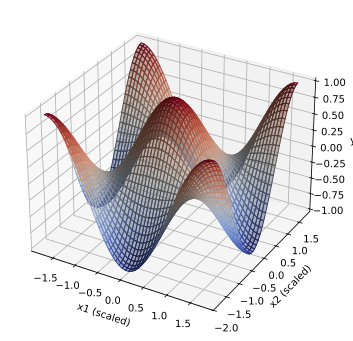

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

x1_grid = torch.linspace(0, 0.1, 50)
x2_grid = torch.linspace(0, 1.0, 50)
X1, X2 = torch.meshgrid(x1_grid, x2_grid, indexing="ij")
x_grid = torch.stack([X1.flatten(), X2.flatten()], dim=1)

x_grid_scaled = torch.tensor(scaler.transform(x_grid.cpu().numpy())).to(device)
Z = gp.mean_module(x_grid_scaled.unsqueeze(0))[0, ...]

X1_scaled = x_grid_scaled[:, 0].reshape(50, 50).cpu().numpy()
X2_scaled = x_grid_scaled[:, 1].reshape(50, 50).cpu().numpy()
Z_grid = Z.reshape(50, 50).detach().cpu().numpy()

ax.plot_surface(
    X1_scaled,
    X2_scaled,
    Z_grid,
    facecolors=plt.cm.coolwarm((Z_grid - Z_grid.min()) / (Z_grid.max() - Z_grid.min())),
    alpha=0.4,
)

ax.set_xlabel("x1 (scaled)")
ax.set_ylabel("x2 (scaled)")
ax.set_zlabel("y")
plt.tight_layout()
plt.show()

In [ ]:
x1_pred = torch.linspace(0, 0.1, 100).to(device)
x2_values = torch.tensor([0.1, 0.5, 0.9]).to(device)
x_pred = torch.stack(
    [
        x1_pred.unsqueeze(0).expand(len(x2_values), -1),
        x2_values.unsqueeze(1).expand(-1, len(x1_pred)),
    ],
    dim=-1,
)

gp.eval()
with torch.no_grad():
    x_pred_flat = x_pred.detach().cpu().flatten(0, -2)
    x_pred_scaled = (
        torch.from_numpy(scaler.transform(x_pred_flat))
        .float()
        .to(device)
        .reshape(x_pred.shape)
    )
    mean_q = gp.mean_quantiles_mc(x_pred_scaled.flatten(0, -2)).unflatten(
        -2, x_pred.shape[:-1]
    )

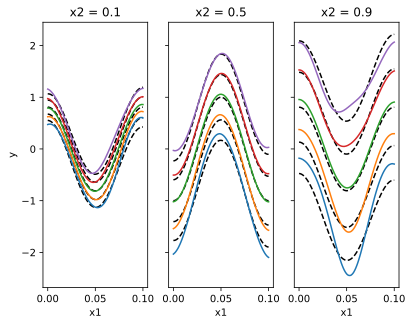

In [ ]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)

    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="k")

    for j in range(len(q)):
        ax.plot(x_line[..., 0].cpu(), mean_q[i, ..., j].cpu(), color=colors[j])

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()